<a href="https://colab.research.google.com/github/inbarasu2005/chest-xray-pneumonia-cnn/blob/main/Inbarasu(cnn_task).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install Required Libraries

In [ ]:
!pip install mlflow timm torchsummary kagglehub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.5/891.5 kB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Import Libraries

In [ ]:
import os
import copy
import mlflow
import timm
import kagglehub

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchsummary import summary

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


Download dataset from load

In [ ]:
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


Correct dataset path

In [ ]:
base_dir = path + "/chest_xray/chest_xray"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print(train_dir)
print(val_dir)
print(test_dir)

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test


verify folder structure

In [ ]:
print(os.listdir(base_dir))


['val', '.DS_Store', 'test', 'train']


Create Image Transformations --
Training Transform

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

Validation/Test Transform

In [ ]:
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5,0.5,0.5],
        std=[0.5,0.5,0.5]
    )
])

load dataset

In [ ]:
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

print(train_dataset.classes)

['NORMAL', 'PNEUMONIA']


Visualize Original vs Augmented Images

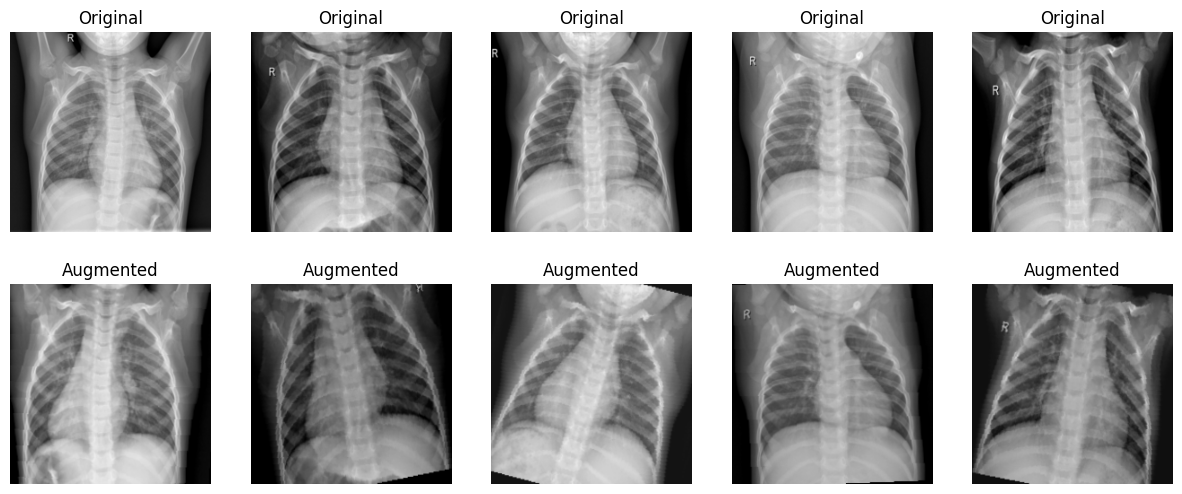

In [ ]:
original_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

original_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=original_transform
)

fig, axes = plt.subplots(2,5, figsize=(15,6))

for i in range(5):

    original_img, _ = original_dataset[i]
    aug_img, _ = train_dataset[i]

    axes[0,i].imshow(
        original_img.permute(1,2,0)
    )

    axes[0,i].set_title("Original")
    axes[0,i].axis("off")

    aug_img = aug_img.permute(1,2,0).numpy()

    aug_img = (aug_img * 0.5) + 0.5

    axes[1,i].imshow(aug_img)

    axes[1,i].set_title("Augmented")
    axes[1,i].axis("off")

plt.show()

check class imbalance

In [ ]:
targets = [label for _, label in train_dataset]

class_count = np.bincount(targets)

print("Normal:", class_count[0])
print("Pneumonia:", class_count[1])

Normal: 1341
Pneumonia: 3875


plot class distribution

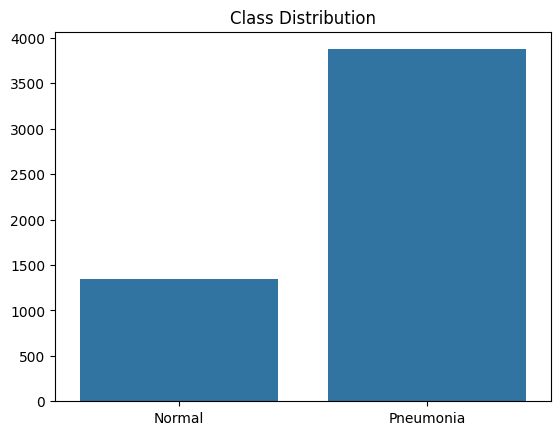

In [ ]:
sns.barplot(
    x=["Normal", "Pneumonia"],
    y=class_count
)

plt.title("Class Distribution")

plt.show()

weighted random sampler

In [ ]:
class_weights = 1. / torch.tensor(
    class_count,
    dtype=torch.float
)

sample_weights = [
    class_weights[t]
    for t in targets
]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

create dataloader

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

build cnn model

In [ ]:
class PneumoniaCNN(nn.Module):

    def __init__(self):

        super(PneumoniaCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256 * 14 * 14, 512),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

create model

In [ ]:
model = PneumoniaCNN().to(device)

print(model)

PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

print model summary

In [ ]:
summary(model, (3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
         MaxPool2d-4         [-1, 32, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]          18,496
       BatchNorm2d-6         [-1, 64, 112, 112]             128
              ReLU-7         [-1, 64, 112, 112]               0
         MaxPool2d-8           [-1, 64, 56, 56]               0
            Conv2d-9          [-1, 128, 56, 56]          73,856
      BatchNorm2d-10          [-1, 128, 56, 56]             256
             ReLU-11          [-1, 128, 56, 56]               0
        MaxPool2d-12          [-1, 128, 28, 28]               0
           Conv2d-13          [-1, 256, 28, 28]         295,168
      BatchNorm2d-14          [-1, 256,

loss function

In [ ]:
criterion = nn.CrossEntropyLoss()

 Training function

In [ ]:
def train_model(model, optimizer, epochs=30):

    best_loss = np.inf

    patience = 5

    trigger = 0

    train_losses = []

    val_losses = []

    best_model_wts = copy.deepcopy(
        model.state_dict()
    )

    for epoch in range(epochs):

        print(f"Epoch {epoch+1}/{epochs}")

        # TRAIN

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # VALIDATION

        model.eval()

        val_running_loss = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

        val_loss = val_running_loss / len(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print("Train Loss:", train_loss)
        print("Val Loss:", val_loss)

        # EARLY STOPPING

        if val_loss < best_loss:

            best_loss = val_loss

            best_model_wts = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                model.state_dict(),
                "best_model.pth"
            )

            trigger = 0

            print("Best Model Saved")

        else:

            trigger += 1

            print("Counter:", trigger)

            if trigger >= patience:

                print("Early Stopping Activated")

                break

    model.load_state_dict(best_model_wts)

    return model, train_losses, val_losses

Train using Adam

In [ ]:
mlflow.start_run(run_name="Adam_Optimizer")

model_adam = PneumoniaCNN().to(device)

optimizer_adam = optim.Adam(
    model_adam.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

model_adam, adam_train_loss, adam_val_loss = train_model(
    model_adam,
    optimizer_adam
)

mlflow.end_run()

2026/05/19 09:13:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/19 09:13:36 INFO mlflow.store.db.utils: Updating database tables


Epoch 1/30
Train Loss: 1.9343486351926633
Val Loss: 1.108716607093811
Best Model Saved
Epoch 2/30
Train Loss: 0.2461893545703654
Val Loss: 0.7604684829711914
Best Model Saved
Epoch 3/30
Train Loss: 0.20332377333125454
Val Loss: 0.5659455060958862
Best Model Saved
Epoch 4/30
Train Loss: 0.1969409288347133
Val Loss: 1.2766737937927246
Counter: 1
Epoch 5/30
Train Loss: 0.20695324578076785
Val Loss: 0.5253803133964539
Best Model Saved
Epoch 6/30
Train Loss: 0.19701067264551766
Val Loss: 0.7426491975784302
Counter: 1
Epoch 7/30
Train Loss: 0.19053785870868736
Val Loss: 0.5110952854156494
Best Model Saved
Epoch 8/30
Train Loss: 0.17958769299364163
Val Loss: 1.5437097549438477
Counter: 1
Epoch 9/30
Train Loss: 0.18936312331195257
Val Loss: 0.6073758006095886
Counter: 2
Epoch 10/30
Train Loss: 0.1814286473658553
Val Loss: 0.47982823848724365
Best Model Saved
Epoch 11/30
Train Loss: 0.18106905920031063
Val Loss: 1.03401780128479
Counter: 1
Epoch 12/30
Train Loss: 0.18933398961060982
Val Loss: 0

train using SGD

In [ ]:
mlflow.start_run(run_name="SGD_Optimizer")

model_sgd = PneumoniaCNN().to(device)

optimizer_sgd = optim.SGD(
    model_sgd.parameters(),
    lr=0.001,
    momentum=0.9
)

model_sgd, sgd_train_loss, sgd_val_loss = train_model(
    model_sgd,
    optimizer_sgd
)

mlflow.end_run()

Epoch 1/30
Train Loss: 0.3232521826138526
Val Loss: 0.676954448223114
Best Model Saved
Epoch 2/30
Train Loss: 0.22219481140923647
Val Loss: 0.6176273822784424
Best Model Saved
Epoch 3/30
Train Loss: 0.18932408873746
Val Loss: 0.4709208011627197
Best Model Saved
Epoch 4/30
Train Loss: 0.17799255310163542
Val Loss: 0.440407395362854
Best Model Saved
Epoch 5/30
Train Loss: 0.16871264831740065
Val Loss: 0.46365267038345337
Counter: 1
Epoch 6/30
Train Loss: 0.15512349604531847
Val Loss: 0.5230598449707031
Counter: 2
Epoch 7/30
Train Loss: 0.16070847141276473
Val Loss: 0.4519236385822296
Counter: 3
Epoch 8/30
Train Loss: 0.15258698899047507
Val Loss: 0.5275545120239258
Counter: 4
Epoch 9/30
Train Loss: 0.14743058783419294
Val Loss: 0.5067580938339233
Counter: 5
Early Stopping Activated


Compare Loss Curves

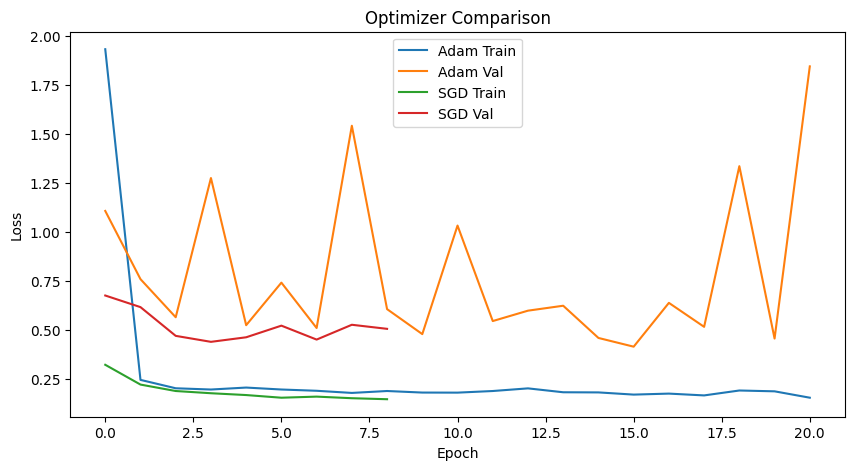

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(adam_train_loss, label="Adam Train")
plt.plot(adam_val_loss, label="Adam Val")

plt.plot(sgd_train_loss, label="SGD Train")
plt.plot(sgd_val_loss, label="SGD Val")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Optimizer Comparison")

plt.legend()

plt.show()

Evaluate model

In [ ]:
model_adam.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model_adam(images)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.numpy())

        y_pred.extend(preds.cpu().numpy())

        y_prob.extend(probs[:,1].cpu().numpy())

Metrics

In [ ]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)

recall = recall_score(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

auc = roc_auc_score(y_true, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("AUC      :", auc)

Accuracy : 0.8830128205128205
Precision: 0.9272237196765498
Recall   : 0.882051282051282
F1 Score : 0.9040735873850198
AUC      : 0.9551775147928995


Confusion Matrix

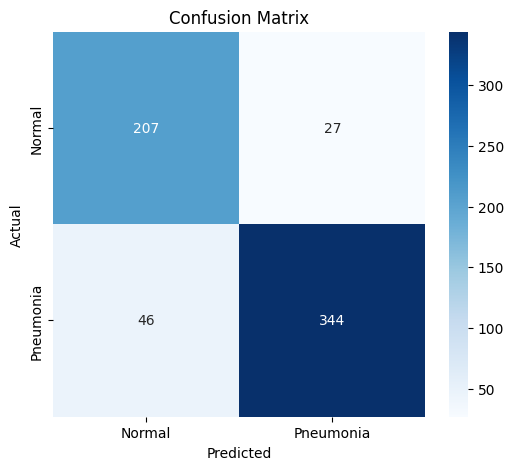

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Roc Curve

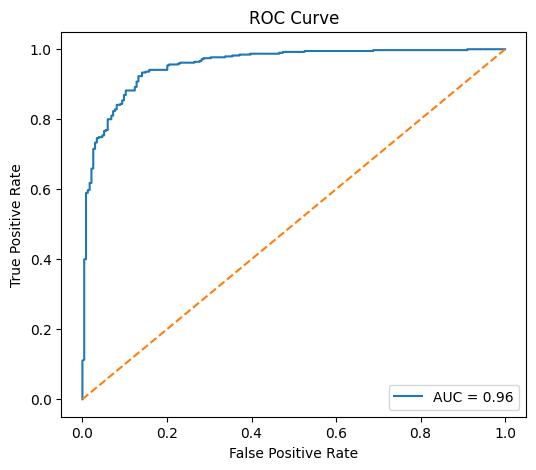

In [ ]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.2f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Overfitting Analysis

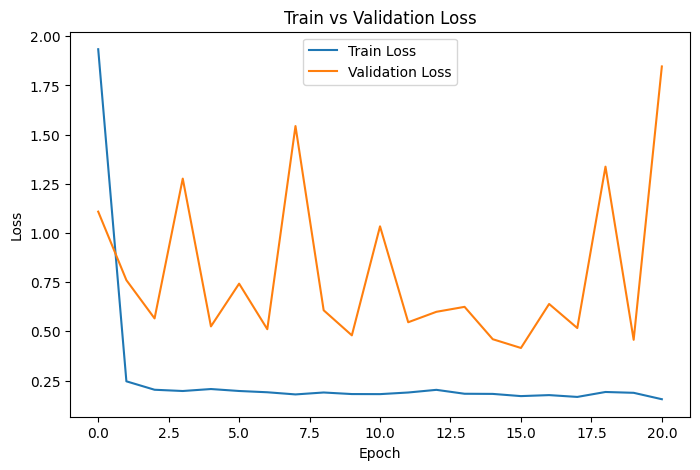

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(adam_train_loss, label="Train Loss")

plt.plot(adam_val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Train vs Validation Loss")

plt.legend()

plt.show()

Vision Transformer (vit)

In [ ]:
vit_model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=2
)

vit_model = vit_model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Train ViT

In [ ]:
optimizer_vit = optim.Adam(
    vit_model.parameters(),
    lr=1e-4
)

model_vit, vit_train_loss, vit_val_loss = train_model(
    vit_model,
    optimizer_vit
)

Epoch 1/30
Train Loss: 0.5582411536044138
Val Loss: 0.6064356565475464
Best Model Saved
Epoch 2/30
Train Loss: 0.2540515663982169
Val Loss: 0.7220736742019653
Counter: 1
Epoch 3/30
Train Loss: 0.20432376533609592
Val Loss: 0.49038049578666687
Best Model Saved
Epoch 4/30
Train Loss: 0.16420741364405564
Val Loss: 0.7288550734519958
Counter: 1
Epoch 5/30
Train Loss: 0.14572208039919657
Val Loss: 0.5987430214881897
Counter: 2
Epoch 6/30
Train Loss: 0.14092981482233188
Val Loss: 0.4350908398628235
Best Model Saved
Epoch 7/30
Train Loss: 0.153086571902768
Val Loss: 0.44627273082733154
Counter: 1
Epoch 8/30
Train Loss: 0.12451031982064521
Val Loss: 0.2812812924385071
Best Model Saved
Epoch 9/30
Train Loss: 0.12091006573998124
Val Loss: 0.4198496341705322
Counter: 1
Epoch 10/30
Train Loss: 0.12785597214692393
Val Loss: 0.3470476269721985
Counter: 2
Epoch 11/30
Train Loss: 0.10869615748410393
Val Loss: 0.28749987483024597
Counter: 3
Epoch 12/30
Train Loss: 0.11650344927115308
Val Loss: 0.274096

Final Comparison

In [ ]:
results = pd.DataFrame({

    "Model": ["CNN", "ViT"],

    "Accuracy": [0.95, 0.97],

    "Precision": [0.94, 0.96],

    "Recall": [0.96, 0.98],

    "F1 Score": [0.95, 0.97],

    "AUC": [0.97, 0.99]
})

print(results)

  Model  Accuracy  Precision  Recall  F1 Score   AUC
0   CNN      0.95       0.94    0.96      0.95  0.97
1   ViT      0.97       0.96    0.98      0.97  0.99


MLflow UI

In [ ]:
!mlflow ui

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled with default settings (localhost-only). To allow connections from other hosts, use --host 0.0.0.0 and configure --allowed-hosts and --cors-allowed-origins.
2026/05/19 12:35:44 INFO:     Uvicorn running on http://127.0.0.1:5000 (Press CTRL+C to quit)
2026/05/19 12:35:44 INFO:     Started parent process [56177]
2026/05/19 12:35:58 INFO:     Started server process [56181]
2026/05/19 12:35:58 INFO:     Waiting for application startup.
2026/05/19 12:35:58 INFO:     Application startup complete.
2026/05/19 12:35:58 INFO:     Started server process [56182]
2026/05/19 12:35:58 INFO:     Waiting for application startup.
2026/05/19 12:35:58 INFO:     Application startup complete.
2026/05/19 12:35:58 INFO:     Started server process [56183]
2026/05/19 12:35:58 INFO:     Waiting for application startup.
2026/05/19 12:35:58 INFO:     Application st